# Praktikum Pengolahan Citra
## JOBSHEET 04: SEGMENTASI GAMBAR

**Nama:** Intan Nurul Faizia
**NIM:** 3.34.23.2.11


**Dosen Pengampu:** Ir. Prayitno, S.ST., M.T., Ph.D.  
**Program Studi:** STR Teknologi Rekayasa Komputer  
**Politeknik Negeri Semarang**

---
## Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

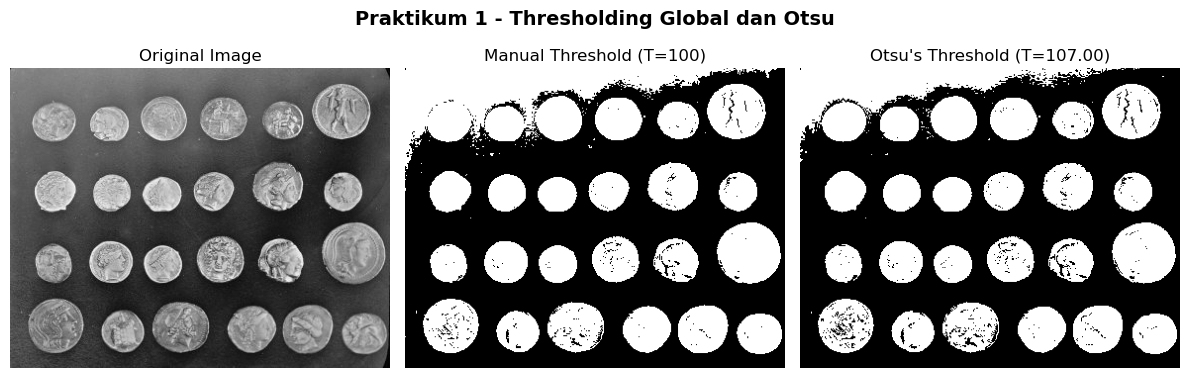

Nilai threshold Otsu yang ditemukan: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.suptitle('Praktikum 1 - Thresholding Global dan Otsu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

---
## Praktikum 2. Segmentasi Menggunakan Region Growing (Flood Fill)

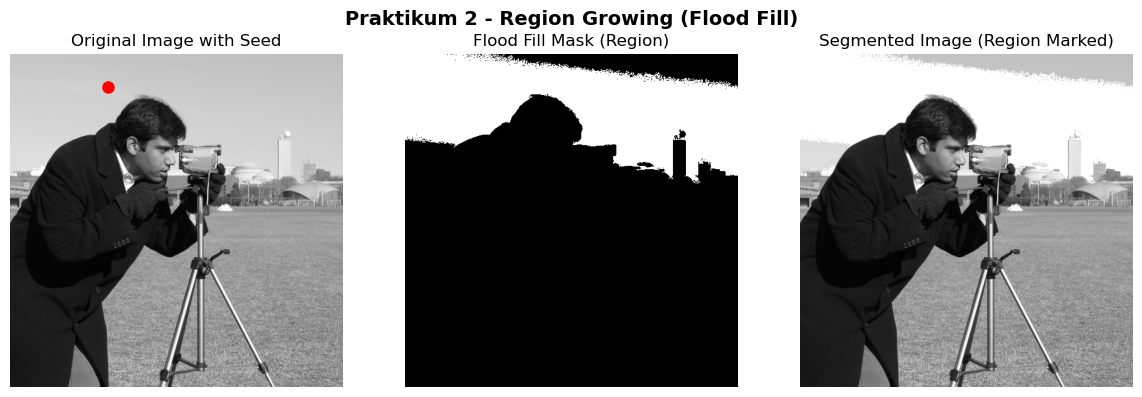

Seed point   : (50, 150)
Toleransi    : 10
Jumlah piksel termasuk region: 58675


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro', markersize=8)
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.suptitle('Praktikum 2 - Region Growing (Flood Fill)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Seed point   : {seed_point}")
print(f"Toleransi    : 10")
print(f"Jumlah piksel termasuk region: {flood_mask.sum()}")

---
## Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

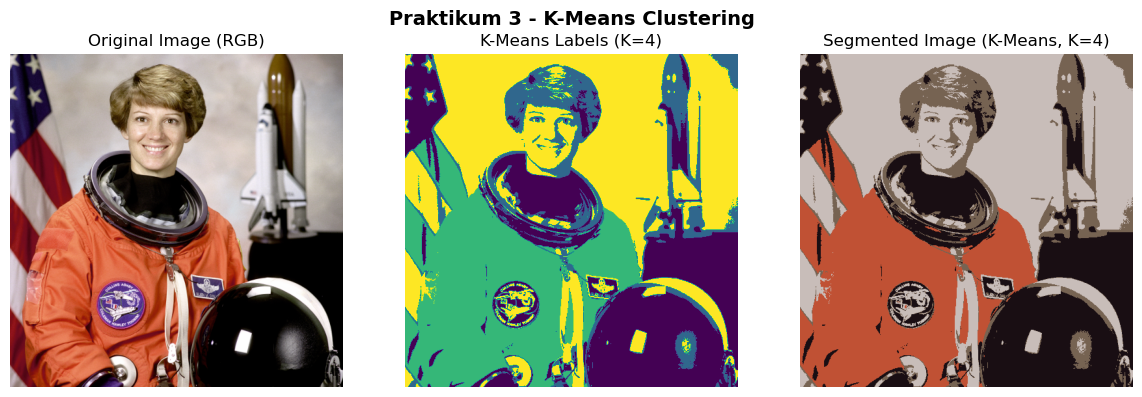

Jumlah klaster (K)   : 4
Ukuran citra         : (512, 512, 3)
Total piksel         : 262144


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro       = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array piksel & konversi ke Lab
image_lab      = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering (K=4)
n_clusters = 4
kmeans     = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    mask_k = pixel_labels.reshape(rows, cols) == k
    segmented_image_kmeans[mask_k] = centers_lab[k]

segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.suptitle('Praktikum 3 - K-Means Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Jumlah klaster (K)   : {n_clusters}")
print(f"Ukuran citra         : {image_astro.shape}")
print(f"Total piksel         : {rows * cols}")

---
## Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

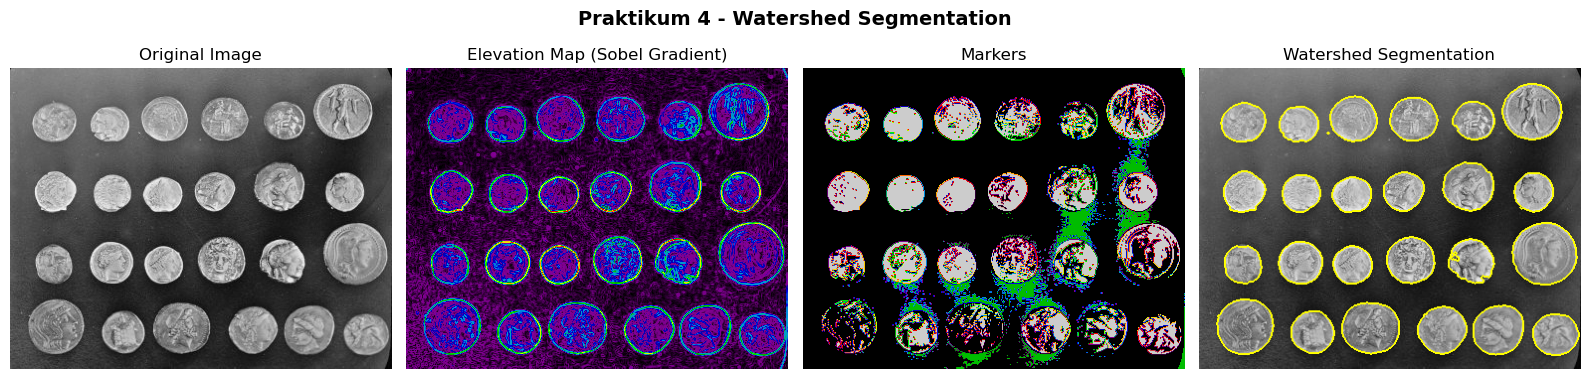

Jumlah region hasil Watershed: 2


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker
markers = np.zeros_like(image_coins)
markers[image_coins < 30]  = 1  # Marker latar belakang
markers[image_coins > 150] = 2  # Marker objek (koin)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)
segmented_colored      = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.suptitle('Praktikum 4 - Watershed Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Jumlah region hasil Watershed: {segmentation_watershed.max()}")

---
## Praktikum 5. Perbandingan Visual Hasil Segmentasi

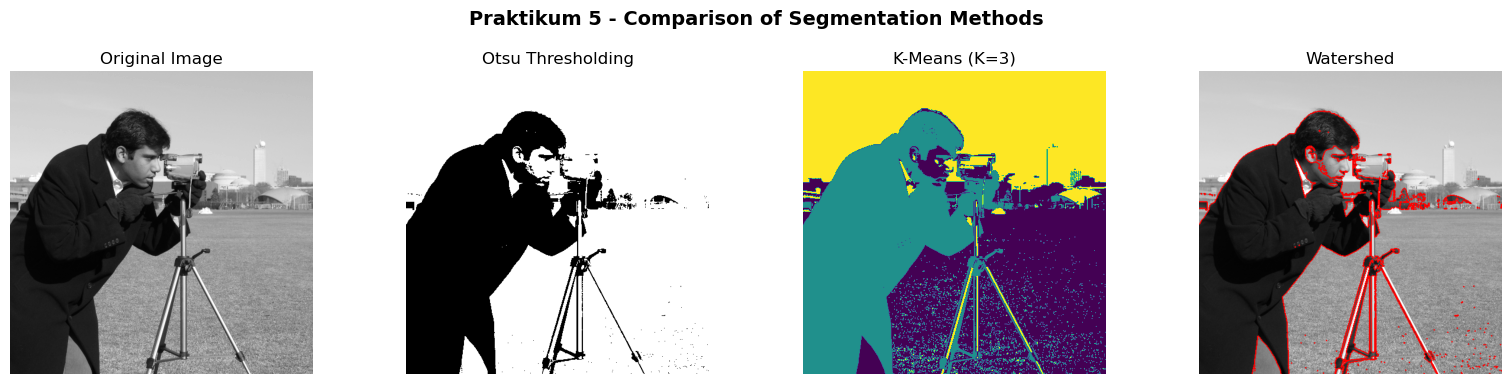

In [5]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan
image       = data.camera()
image_float = img_as_float(image)

# 2a. Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 2b. K-Means (K=3)
rows, cols      = image.shape
pixel_features  = image_float.reshape(rows * cols, 1)
n_clusters      = 3
kmeans          = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# 2c. Watershed
elevation_map          = filters.sobel(image)
markers                = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float, segmentation_watershed, color=(1, 0, 0)
)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Praktikum 5 - Comparison of Segmentation Methods',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()